In [1]:
import yaml
import sys
import os
import pandas as pd
import numpy as np
import torch
import matplotlib as mpl
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from pathlib import Path
import mplhep as hep
import random

hep.style.use("CMS")
# hep.style.use("firamath")

import models.training_utils as training_utils
from models.training_utils import sigmoid_upweight

```bash
python3 -m models.get_prediction --model_folder Version_20250524_MVAID_forPreApp/after_random_search_best1 --samples_path Version_20250524_MVAID_forPreApp --config_path config/Version_20250524_MVAID_forPreApp --get_pred_nominal
```

In [2]:
ERAS = ['preEE', 'postEE', 'preBPix', 'postBPix']
SAMPLES = [
    "BBHto2G_M_125",
    "DDQCDGJET",
    "GGJets",
    "GluGluHToGG_M_125",
    "GluGlutoHHto2B2G_kl_0p00_kt_1p00_c2_0p00",
    "GluGlutoHHto2B2G_kl_1p00_kt_1p00_c2_0p00",
    "GluGlutoHHto2B2G_kl_2p45_kt_1p00_c2_0p00",
    "GluGlutoHHto2B2G_kl_5p00_kt_1p00_c2_0p00",
    "TTGG",
    "TTG_100_200",
    "TTG_200",
    "VBFHToGG_M_125",
    "VHtoGG_M_125",
    "ttHtoGG_M_125",
]

def all_preds_exist(sample_base_path: Path, eras=ERAS, samples=SAMPLES) -> bool:
    file_exists = {}
    for era in eras:
        for sample in samples:
            sample_path = sample_base_path / era / sample / "y.npy"
            if not sample_path.exists():
                file_exists[f"{era}/{sample}"] = False
            else:
                file_exists[f"{era}/{sample}"] = True
    
    for key, exists in file_exists.items():
        if not exists:
            print(f"Missing prediction file for: {key}")

    if any(not exists for exists in file_exists.values()):
        return False

    return True

if all_preds_exist(Path("Version_20250524_MVAID_forPreApp/individual_samples")):
    print("All prediction files exist.")
else:
    print("Some prediction files are missing.")


def mean(x, w):
    return np.sum(x * w) / np.sum(w)

def cov(x, y, w):
    mean_x = mean(x, w)
    mean_y = mean(y, w)
    return np.sum(w * (x - mean_x) * (y - mean_y)) / np.sum(w)

def corr(x, y, w):
    return cov(x, y, w) / (np.sqrt(cov(x, x, w)) * np.sqrt(cov(y, y, w)))


def load(path: Path, eras=ERAS, samples=SAMPLES) -> pd.DataFrame:
    df_list = []
    for era in eras:
        for sample in samples:
            sample_path_preds = path / era / sample / "y.npy"
            sample_path_relw = path / era / sample / "rel_w.npy"
            sample_path_x = path / era / sample / "X.npy"
            y = np.load(sample_path_preds)
            rel_w = np.load(sample_path_relw)
            with open(path / era / sample / "events.parquet", "rb") as f:
                df_events = pd.read_parquet(f)
            n_events = y.shape[0]
            df_temp = pd.DataFrame({
                "era": [era] * n_events,
                "sample": [sample] * n_events,
                "nonRes_score": y[:, 0],
                "ttH_score": y[:, 1],
                "singleH_score": y[:, 2],
                "HH_score": y[:, 3],
                "rel_w": rel_w,
                "mass": df_events["mass"].values,
                "nonResReg_dijet_mass_DNNreg": df_events["nonResReg_dijet_mass_DNNreg"].values,
                "weight_tot": df_events["weight_tot"].values,
            })
            df_list.append(df_temp)
            print(f"loaded {era}/{sample}: {n_events:>2} events")
    df = pd.concat(df_list, ignore_index=True)
    return df

df_pred = load(Path("Version_20250524_MVAID_forPreApp/individual_samples"))
mem_bytes = df_pred.memory_usage(deep=True)
print(f"Loaded predictions dataframe with {df_pred.shape[0]} events, memory usage: {mem_bytes.sum() / (1024**2):.2f} MB")

All prediction files exist.
loaded preEE/BBHto2G_M_125: 6548 events
loaded preEE/DDQCDGJET: 11051 events
loaded preEE/GGJets: 447000 events
loaded preEE/GluGluHToGG_M_125: 64413 events
loaded preEE/GluGlutoHHto2B2G_kl_0p00_kt_1p00_c2_0p00: 37627 events
loaded preEE/GluGlutoHHto2B2G_kl_1p00_kt_1p00_c2_0p00: 40741 events
loaded preEE/GluGlutoHHto2B2G_kl_2p45_kt_1p00_c2_0p00: 43528 events
loaded preEE/GluGlutoHHto2B2G_kl_5p00_kt_1p00_c2_0p00: 33805 events
loaded preEE/TTGG: 21744 events
loaded preEE/TTG_100_200: 1503 events
loaded preEE/TTG_200: 442 events
loaded preEE/VBFHToGG_M_125: 39024 events
loaded preEE/VHtoGG_M_125: 38338 events
loaded preEE/ttHtoGG_M_125: 66176 events
loaded postEE/BBHto2G_M_125: 21610 events
loaded postEE/DDQCDGJET: 38083 events
loaded postEE/GGJets: 1385886 events
loaded postEE/GluGluHToGG_M_125: 215689 events
loaded postEE/GluGlutoHHto2B2G_kl_0p00_kt_1p00_c2_0p00: 131573 events
loaded postEE/GluGlutoHHto2B2G_kl_1p00_kt_1p00_c2_0p00: 135907 events
loaded postEE

Using device: mps


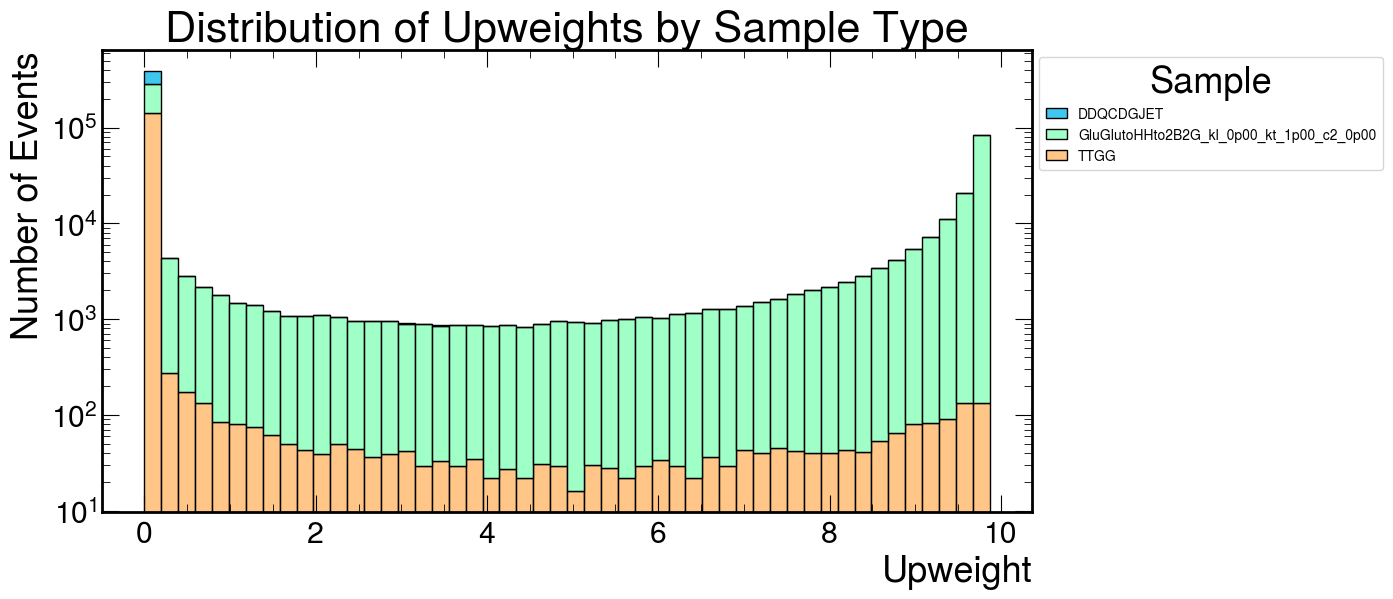

['DDQCDGJET', 'GluGlutoHHto2B2G_kl_0p00_kt_1p00_c2_0p00', 'TTGG']


In [3]:
with open("config/Version_20250524_MVAID_forPreApp/training_config.yaml", "r") as f:
    training_config = yaml.safe_load(f)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

upweight_params = training_config["upweight_params"]
upweight_score_midpoint = torch.tensor(
    training_utils._extract_ordered_values(upweight_params["sr_definition"]["score_midpoint"]),
    device=device,
    dtype=torch.float32,
)
upweight_score_90_percent = torch.tensor(
    training_utils._extract_ordered_values(upweight_params["sr_definition"]["score_90_percent"]),
    device=device,
    dtype=torch.float32,
)
upweight_max = float(upweight_params["max_upweight"])
upweight_min = float(upweight_params["min_upweight"])


def sigmoid_score(df, score_midpoint, score_90_percent, upweight_max, upweight_min, batch_size=1024):
    y_pred = torch.tensor(
        df[["nonRes_score", "ttH_score", "singleH_score", "HH_score"]].values,
        device=device,
        dtype=torch.float32,
    )
    n_events = y_pred.shape[0]
    upweights: list[float] = []
    for start_idx in range(0, n_events, batch_size):
        end_idx = min(start_idx + batch_size, n_events)
        y_pred_batch = y_pred[start_idx:end_idx, 3] # 3 only HH score, use [0,1,2,3] for others
        upweight_batch = sigmoid_upweight(y_pred_batch, x0=score_midpoint, x90=score_90_percent, y_max=upweight_max, y_min=upweight_min, softmax=False)
        upweights.append(upweight_batch.cpu().numpy())
    upweights_concat = np.concatenate(upweights, axis=0)
    return upweights_concat

df_pred["upweight"] = sigmoid_score(
    df_pred,
    score_midpoint=upweight_score_midpoint,
    score_90_percent=upweight_score_90_percent,
    upweight_max=upweight_max,
    upweight_min=upweight_min,
)


df_pred["uniform_sample_weight"] = -1.0
for sample in df_pred["sample"].unique():
    n_events = df_pred[df_pred["sample"] == sample].shape[0]
    df_pred.loc[df_pred["sample"] == sample, "uniform_sample_weight"] = n_events / df_pred.shape[0]


SELECTED_SAMPLES = [
    "GluGlutoHHto2B2G_kl_0p00_kt_1p00_c2_0p00",
    "TTGG",
    "DDQCDGJET",
]

# Stacked histogram stratified on sample type with rainbow color scale
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    data=df_pred[df_pred["sample"].isin(SELECTED_SAMPLES)] if SELECTED_SAMPLES else df_pred,
    x="upweight",
    hue="sample",
    multiple="stack",
    bins=50,
    kde=False,
    palette="rainbow",
    legend=True,
    ax=ax,
)
plt.title("Distribution of Upweights by Sample Type")
plt.xlabel("Upweight")
plt.ylabel("Number of Events")
legend = ax.get_legend()
handles = legend.legend_handles
labels = [text.get_text() for text in legend.get_texts()]
ax.legend(handles, labels, title="Sample", bbox_to_anchor=(1, 1), loc='upper left', frameon=True, ncol=1, fontsize=10)
plt.yscale("log")
plt.show()
print(labels)



In [4]:
df_pred["upweight"].describe()

count    6.765700e+06
mean     8.637146e-01
std      2.655524e+00
min      6.662522e-17
25%      6.662522e-17
50%      1.078560e-16
75%      9.022916e-15
max      9.869968e+00
Name: upweight, dtype: float64

In [5]:
# upper 10% of scores per sample
def get_upper_10_percent_scores(df: pd.DataFrame, percentile: float) -> pd.DataFrame:
    upper_10_percent_scores = {}
    for sample in df["sample"].unique():
        df_sample = df[df["sample"] == sample]
        score_thresholds = {}
        for score_col in ["nonRes_score", "ttH_score", "singleH_score", "HH_score"]:
            threshold = np.percentile(df_sample[score_col], percentile)
            score_thresholds[score_col] = threshold
        upper_10_percent_scores[sample] = score_thresholds
    return pd.DataFrame.from_dict(upper_10_percent_scores, orient='index')

df_percentile = pd.DataFrame()
df_percentile["upper_10"] = get_upper_10_percent_scores(df_pred, 90)["HH_score"]
df_percentile["upper_1"] = get_upper_10_percent_scores(df_pred, 99)["HH_score"]
print(df_percentile)

                                          upper_10   upper_1
BBHto2G_M_125                             0.737227  0.976893
DDQCDGJET                                 0.015331  0.302838
GGJets                                    0.092297  0.661625
GluGluHToGG_M_125                         0.131918  0.786180
GluGlutoHHto2B2G_kl_0p00_kt_1p00_c2_0p00  0.992183  0.996807
GluGlutoHHto2B2G_kl_1p00_kt_1p00_c2_0p00  0.993470  0.997001
GluGlutoHHto2B2G_kl_2p45_kt_1p00_c2_0p00  0.993719  0.997090
GluGlutoHHto2B2G_kl_5p00_kt_1p00_c2_0p00  0.967365  0.994978
TTGG                                      0.351111  0.886083
TTG_100_200                               0.631627  0.954046
TTG_200                                   0.778759  0.972835
VBFHToGG_M_125                            0.108216  0.666623
VHtoGG_M_125                              0.278593  0.959309
ttHtoGG_M_125                             0.359290  0.902966


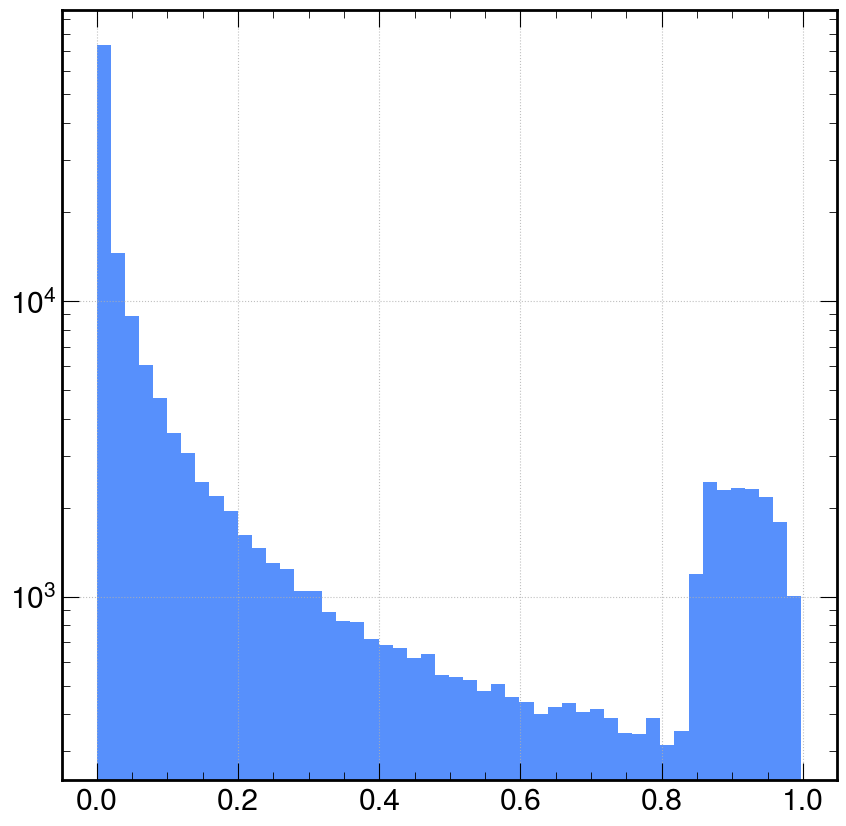

In [6]:
df_pred[((df_pred["sample"] == "TTGG") | ((df_pred["sample"] == "GGJets")) & (df_pred["upweight"] > 0.99))]["HH_score"].hist(bins=50)
plt.yscale("log")

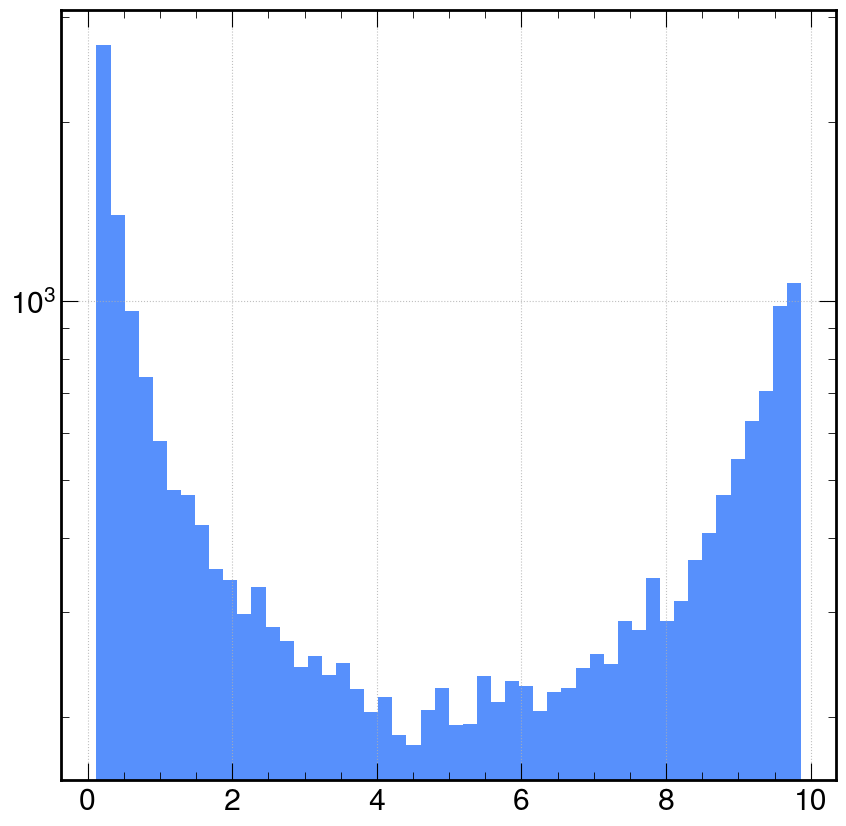

In [7]:
df_pred[((df_pred["sample"] == "TTGG") | (df_pred["sample"] == "GGJets")) & (df_pred["HH_score"] > 0.8)]["upweight"].hist(bins=50)
plt.yscale("log")

Validating HH_score_delta: nominal=0.9354960577617196, delta=0, modified=0.9354960577617196
Validating nonRes_score_delta: nominal=0.00042766399533097953, delta=0, modified=0.00042766399533097953
Validating ttH_score_delta: nominal=0.5339686443021779, delta=0, modified=0.5339686443021779
Validating singleH_score_delta: nominal=0.5221471768416271, delta=0, modified=0.5221471768416271
sample
GGJets       231
TTGG         122
DDQCDGJET      3
Name: count, dtype: int64
KDE density stats: min=7.536816027456497e-06, max=0.0002913701791709399, mean=0.000164672119998913


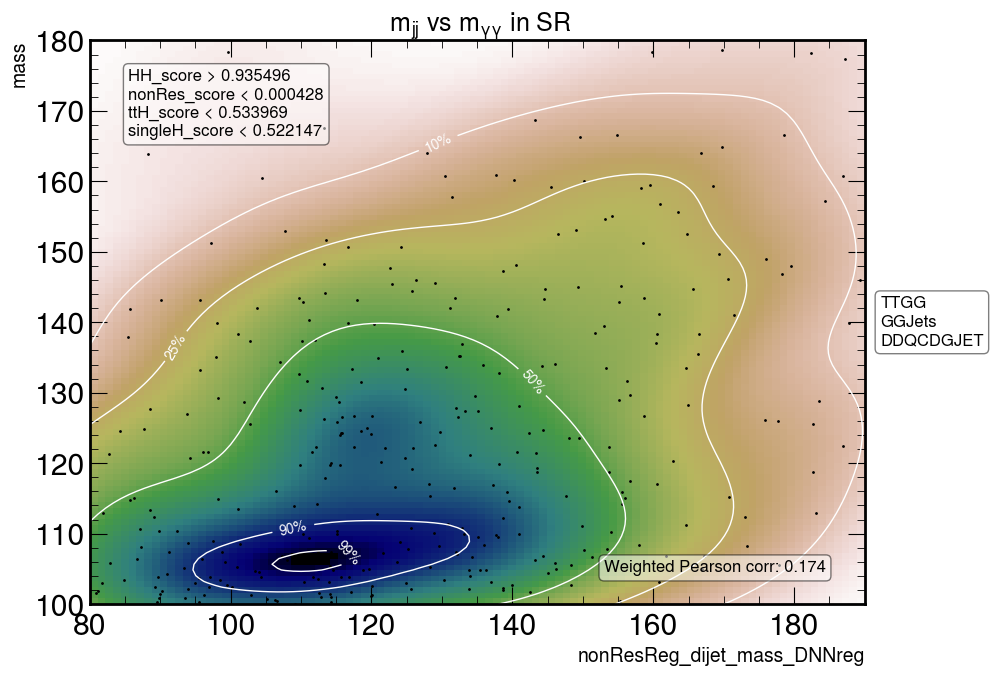

In [ ]:
# 2D histogram of mass vs nonResReg_dijet_mass_DNNreg in the high upweight region
def validate_deltas(deltas: dict[str, float], nominals: dict[str, float]) -> None:
    for dname, dval in deltas.items():
        nominal_value = nominals[dname.replace("_delta", "")]
        modified_value = nominal_value + dval if "HH_score" in dname else nominal_value - dval
        print(f"Validating {dname}: nominal={nominal_value}, delta={dval}, modified={modified_value}")
        if "HH_score" in dname:
            if not (nominal_value + dval) <= 1.0 or not (nominal_value + dval) >= 0.0:
                raise ValueError(f"Invalid delta for {dname}: {dval}, nominal: {nominal_value}")
        else:
            if not (nominal_value - dval) <= 1.0 or not (nominal_value - dval) >= 0.0:
                raise ValueError(f"Invalid delta for {dname}: {dval}, nominal: {nominal_value}")

def parse_human_readable_delta_part(delta_name: str, delta_value: float, nominal_value: float) -> str:
    """
    delta_value positive -> tighter
    delta_value negative -> looser

    wordy:
    HH_score > 0.9354 + 0.025 (tighter)
    nonRes_score < 0.0004277 - 0.03 (tighter)
    ttH_score < 0.53397
    singleH_score < 0.52215 + 0.01 (looser)
    """
    name = delta_name.replace("_delta", "")
    ineq = ">" if "HH_score" in delta_name else "<"
    # + if tighter and >
    # + if looser and <
    # - if tighter and <
    # - if looser and >
    if delta_value > 0 and "HH_score" in delta_name:
        pn = "+"
    elif delta_value < 0 and "HH_score" in delta_name:
        pn = "-"
    elif delta_value > 0 and "HH_score" not in delta_name:
        pn = "-"
    elif delta_value < 0 and "HH_score" not in delta_name:
        pn = "+"
    else:
        pn = "N/A"

    actual_criteria = nominal_value + delta_value if "HH_score" in delta_name else nominal_value - delta_value
    if actual_criteria < 0.0 or actual_criteria > 1.0:
        raise ValueError(f"Invalid modified criteria for {delta_name}: nominal={nominal_value}, delta={delta_value}, modified={actual_criteria}")
    if round(actual_criteria, 5) == 1.0 and ineq == "<":
        is_inclusive = True
    elif round(actual_criteria, 5) == 0.0 and ineq == ">":
        is_inclusive = True
    else:
        is_inclusive = False

    if delta_value > 0 and not is_inclusive:
        return f"{name} {ineq} {nominal_value:.6f} {pn} {abs(delta_value):.6f} (tighter)"
    elif delta_value < 0 and not is_inclusive:
        return f"{name} {ineq} {nominal_value:.6f} {pn} {abs(delta_value):.6f} (looser)"
    elif is_inclusive:
        return f"{name} inclusive"
    else:
        return f"{name} {ineq} {nominal_value:.6f}"
        

def human_readable_deltas(deltas: dict[str, float], nominal_values: dict[str, float]) -> str:
    parts = []
    for dname, dval in deltas.items():
        nominal_value = nominal_values[dname.replace("_delta", "")]
        part = parse_human_readable_delta_part(dname, dval, nominal_value)
        parts.append(part)
    return "\n".join(parts)


def sr_mask_with_deltas(df: pd.DataFrame, deltas: dict[str, float], nominal_values: dict[str, float]) -> pd.Series:
    HH_score_delta = deltas["HH_score_delta"]
    nonRes_score_delta = deltas["nonRes_score_delta"]
    ttH_score_delta = deltas["ttH_score_delta"]
    singleH_score_delta = deltas["singleH_score_delta"]

    sr_mask = (
        (df["HH_score"] > nominal_values["HH_score"] + HH_score_delta) &
        (df["nonRes_score"] < nominal_values["nonRes_score"] - nonRes_score_delta) &
        (df["ttH_score"] < nominal_values["ttH_score"] - ttH_score_delta) &
        (df["singleH_score"] < nominal_values["singleH_score"] - singleH_score_delta)
    )
    return sr_mask


def plot_correlation_2d(
        df: pd.DataFrame, 
        samples: list[str], 
        deltas: dict[str, float], 
        nominal_cats: dict[str, float], 
        fname: str = "", 
        subsamp: float = 1.0, 
        nmax: int = 0,
        use_weights: bool = True,
        weightcol: str = "weight_tot",
    ):
    validate_deltas(deltas, nominal_cats)
    # df = df.sample(frac=subsamp)

    for s in samples:
        if s not in df["sample"].unique():
            print(f"Warning: Sample {s} not found in dataframe samples.")
    # sr1_mask = (df["HH_score"] > 0.9354960577617196 + HH_score_delta) & (df["nonRes_score"] < 0.00042766399533097953 - nonRes_score_delta) & (df["ttH_score"] < 0.5339686443021779 - ttH_score_delta) & (df["singleH_score"] < 0.5221471768416271 - singleH_score_delta)
    sr1_mask = sr_mask_with_deltas(df, deltas, nominal_cats)
    include_samples_mask = df["sample"].isin(samples)
    df_sr1 = df[sr1_mask & include_samples_mask]
    # df_pred_sample_excl = df_sr1[df_sr1["sample"].isin(samples)]
    # df_pred_sample_excl = df_sr1[(df_sr1["sample"] == "TTGG") | (df_sr1["sample"] == "GGJets")]
    df_pred_sample_excl = df_sr1

    if not use_weights:
        weighted_pearson_corr = corr(df_pred_sample_excl["mass"].values, df_pred_sample_excl["nonResReg_dijet_mass_DNNreg"].values, df_pred_sample_excl[weightcol].values)
        if nmax > 0 and len(df_pred_sample_excl) > nmax:
            df_pred_sample_excl = df_pred_sample_excl.sample(n=nmax)
        elif nmax == 0 and subsamp < 1.0:
            df_pred_sample_excl = df_pred_sample_excl.sample(frac=subsamp)
    else:
        # subsample df based on weights
        weights = abs(df_pred_sample_excl[weightcol].values)
        prob = weights / weights.sum()
        # expectation of len(df) after weight sampling
        if nmax > 0 and len(df_pred_sample_excl) > nmax:
            expectation_n = nmax
        elif nmax == 0 and subsamp < 1.0:
            expectation_n = len(df_pred_sample_excl) * subsamp
        else:
            expectation_n = len(df_pred_sample_excl)
        sampled_indices = np.random.choice(
            df_pred_sample_excl.index,
            size=int(expectation_n),
            replace=False,
            p=prob,
        )
        print(f"Subsampling from {len(df_pred_sample_excl)} to {len(sampled_indices)} events based on weights.")
        df_pred_sample_excl = df_pred_sample_excl.loc[sampled_indices]
        weighted_pearson_corr = corr(
            df_pred_sample_excl["mass"].values,
            df_pred_sample_excl["nonResReg_dijet_mass_DNNreg"].values,
            df_pred_sample_excl[weightcol].values,
        )

    print(df_pred_sample_excl['sample'].value_counts())

    # print(f"Weighted Pearson correlation: {weighted_pearson_corr}")

    # hist, xedges, yedges = np.histogram2d(
    #     df_pred_sample_excl["nonResReg_dijet_mass_DNNreg"],
    #     df_pred_sample_excl["mass"],
    #     bins=1000,
    #     range=[[80, 190], [100, 180]],
    # )

    # Event-wise density estimation based on KDE
    kde = scipy.stats.gaussian_kde(
        np.vstack([
            df_pred_sample_excl["nonResReg_dijet_mass_DNNreg"].values,
            df_pred_sample_excl["mass"].values,
        ]),
        # weights=df_pred_sample_excl["weight_tot"].values, # does not like negative weights
        bw_method="scott"
    )
    event_density = kde(np.vstack([
        df_pred_sample_excl["nonResReg_dijet_mass_DNNreg"].values,
        df_pred_sample_excl["mass"].values,
    ]))
    df_pred_sample_excl = df_pred_sample_excl.assign(density=event_density)
    print(f"KDE density stats: min={df_pred_sample_excl['density'].min()}, max={df_pred_sample_excl['density'].max()}, mean={df_pred_sample_excl['density'].mean()}")

    MJJ, MGG = np.meshgrid(
        np.linspace(80, 190, 100),
        np.linspace(100, 180, 100),
    )
    grid_coords = np.vstack([MJJ.ravel(), MGG.ravel()])
    density = kde(grid_coords).reshape(MJJ.shape)

    # Smooth-ish contours on irregular sparse data
    # triang = mpl.tri.Triangulation(
    #     df_pred_sample_excl["nonResReg_dijet_mass_DNNreg"],
    #     df_pred_sample_excl["mass"],
    # )
    # interpolator = mpl.tri.LinearTriInterpolator(triang, np.ones(triang.x.shape))

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    # plt.hist2d(
    #     df_pred_sample_excl["nonResReg_dijet_mass_DNNreg"],
    #     df_pred_sample_excl["mass"],
    #     bins=100,
    #     cmap='viridis',
    # )
    ax.plot(
        df_pred_sample_excl["nonResReg_dijet_mass_DNNreg"],
        df_pred_sample_excl["mass"],
        'o',
        markersize=1,
        alpha=1.0,
        color='black',
    )

    ax.imshow(
        density,
        cmap=plt.cm.gist_earth_r,
        extent=[80, 190, 100, 180],
        origin='lower',
        alpha=1.0,
    )
    # quantile contours
    # grid = np.meshgrid(
    #     np.linspace(80, 190, 100),
    #     np.linspace(100, 180, 100),
    # ) 
    # plt.contour(
    #     xedges[:-1],
    #     yedges[:-1],

    #     levels=[0.5, 0.9, 0.99],
    #     colors='white',
    #     linewidths=1,
    # )
    # plt.colorbar(label='Counts')
    ax.set_xlabel('nonResReg_dijet_mass_DNNreg', fontsize=14)
    ax.set_ylabel('mass', fontsize=14)
    if len(samples) > 2:
        # Overflow
        sample_str = ""
        # add text box to side of plot with sample names
        props = dict(boxstyle='round', facecolor='white', alpha=0.5)
        ax.text(1.02, 0.5, "\n".join(samples), transform=ax.transAxes, fontsize=12, verticalalignment='center', bbox=props)
    else:
        sample_str = ", ".join(samples)
    ax.set_title(r'%s $m_{jj}$ vs $m_{\gamma\gamma}$ in SR' % sample_str, fontsize=18)
    levels = {
        "10%": 0.1 * density.max(),
        "25%": 0.25 * density.max(),
        "50%": 0.5 * density.max(),
        "90%": 0.9 * density.max(),
        "99%": 0.99 * density.max(),
    }
    cs = ax.contour(
        MJJ,
        MGG,
        density,
        levels=list(levels.values()),
        colors='white',
        linewidths=1,
    )
    ax.clabel(cs, inline=True, fontsize=10, fmt={v: k for k, v in levels.items()})
    # HH_score > 0.9354 + 0.025 (tighter)
    # nonRes_score < 0.0004277 - 0.03 # (tighter)
    # ttH_score < 0.53397 + 0.0 (unchanged)
    # singleH_score < 0.52215 + 0.01 (looser)
    full_human_delta_string = human_readable_deltas(deltas, nominal_cats)
    ax.text(0.05, 0.95, full_human_delta_string, transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.5))
    ax.text(0.95, 0.05, f'Weighted Pearson corr: {weighted_pearson_corr:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='bottom', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.5))
    ax.set_xlim(80, 190)
    ax.set_ylim(100, 180)
    if fname:
        plt.savefig(fname, dpi=300, bbox_inches='tight')
    else:
        plt.show()
    plt.close()


def plot_hist_mass_ranges(
        df: pd.DataFrame, 
        samples: list[str], 
        deltas: dict[str, float], 
        nominal_cats: dict[str, float], 
        weightcol: str = "weight_tot"
    ):
    HH_score_delta = deltas["HH_score_delta"]
    nonRes_score_delta = deltas["nonRes_score_delta"]
    ttH_score_delta = deltas["ttH_score_delta"]
    singleH_score_delta = deltas["singleH_score_delta"]

    validate_deltas(deltas, nominal_cats)

    for s in samples:
        if s not in df["sample"].unique():
            print(f"Warning: Sample {s} not found in dataframe samples.")
    # sr1_mask = (df["HH_score"] > 0.9354960577617196 + HH_score_delta) & (df["nonRes_score"] < 0.00042766399533097953 - nonRes_score_delta) & (df["ttH_score"] < 0.5339686443021779 - ttH_score_delta) & (df["singleH_score"] < 0.5221471768416271 - singleH_score_delta)
    sr1_mask = sr_mask_with_deltas(df, deltas, nominal_cats)
    include_samples_mask = df["sample"].isin(samples)
    df_sr1 = df[sr1_mask & include_samples_mask]
    df_pred_sample_excl = df_sr1

    df_hi = df_pred_sample_excl[df_pred_sample_excl["mass"] >= 125]
    df_lo = df_pred_sample_excl[df_pred_sample_excl["mass"] < 125]

    weighted_pearson_corr = corr(df_pred_sample_excl["mass"].values, df_pred_sample_excl["nonResReg_dijet_mass_DNNreg"].values, df_pred_sample_excl[weightcol].values)

    # 1D hist of nonResReg_dijet_mass_DNNreg in high/low mgg regions
    Nbins = 20
    binedges = np.linspace(80, 190, Nbins + 1)
    plt.figure(figsize=(10, 6))
    plt.hist(
        df_lo["nonResReg_dijet_mass_DNNreg"],
        bins=binedges,
        weights=df_lo[weightcol],
        histtype='step',
        label='mass < 125 GeV',
        color='blue',
        density=True,
    )
    plt.hist(
        df_hi["nonResReg_dijet_mass_DNNreg"],
        bins=binedges,
        weights=df_hi[weightcol],
        histtype='step',
        label='mass >= 125 GeV',
        color='red',
        density=True,
    )
    plt.hist(
        df_pred_sample_excl["nonResReg_dijet_mass_DNNreg"],
        bins=binedges,
        weights=df_pred_sample_excl[weightcol],
        histtype='step',
        label='inclusive',
        color='black',
        density=True,
    )
    plt.xlabel('nonResReg_dijet_mass_DNNreg')
    plt.ylabel('Normalized Counts')
    plt.title(r'Distribution of $m_{jj}$ in Different Mass Regions')
    plt.text(0.7, 0.7, ", ".join(samples), transform=plt.gca().transAxes, fontsize=12)
    plt.text(0.7, 0.65, f'Total Events: {df_pred_sample_excl.shape[0]}', transform=plt.gca().transAxes, fontsize=12)
    plt.text(0.7, 0.6, f'Weighted Pearson corr: {weighted_pearson_corr:.3f}', transform=plt.gca().transAxes, fontsize=12)
    plt.legend(fontsize=12)
    plt.show()


nominal_cats = {
    "HH_score": 0.9354960577617196,
    "nonRes_score": 0.00042766399533097953,
    "ttH_score": 0.5339686443021779,
    "singleH_score": 0.5221471768416271,
}


SAMPLES = [
    "TTGG",
    "GGJets",
    # "GluGlutoHHto2B2G_kl_1p00_kt_1p00_c2_0p00",  # Fixed: "GluGluto" not "GluGluTo"
    # "BBHto2G_M_125",
    # "GluGluHToGG_M_125",
    # "VBFHToGG_M_125",
    # "VHtoGG_M_125",
    # "ttHtoGG_M_125",
    "DDQCDGJET",
    # "TTG_100_200",
    # "TTG_200",
]
# negative -> looser cuts, positive -> tighter cuts
HH_score_delta = -1 * nominal_cats["HH_score"]
nonRes_score_delta = -1 + nominal_cats["nonRes_score"]
ttH_score_delta = -1 + nominal_cats["ttH_score"]
singleH_score_delta = -1 + nominal_cats["singleH_score"]

deltas = {
    "HH_score_delta": HH_score_delta,
    "nonRes_score_delta": nonRes_score_delta,
    "ttH_score_delta": ttH_score_delta,
    "singleH_score_delta": singleH_score_delta,
}

df_pred["rel_w_upweight"] = df_pred["rel_w"] * df_pred["upweight"]

# plot_correlation_2d(df_pred, SAMPLES, deltas, nominal_cats, nmax=10000, use_weights=True, weightcol="rel_w_upweight")
plot_correlation_2d(df_pred, SAMPLES, deltas, nominal_cats, nmax=10000, use_weights=False, weightcol="weight_tot")
# plot_hist_mass_ranges(df_pred, SAMPLES, deltas, nominal_cats)

# Gif varying nonRes_score_delta from -0.2 to 0.0001 in steps of 0.01
if False:
    scan_score = "singleH"
    start = 0.3
    end = -0.1
    steps = 30
    os.makedirs("tmp", exist_ok=True)
    os.system("rm -r tmp/*")
    for idx, singleH_score_delta in enumerate(np.linspace(start, end, steps)):
        n_digits_steps = len(str(steps))
        deltas = {
            "HH_score_delta": HH_score_delta,
            "nonRes_score_delta": nonRes_score_delta,
            "ttH_score_delta": ttH_score_delta,
            "singleH_score_delta": singleH_score_delta,
        }
        frame_no: str = f"{idx:0{n_digits_steps}d}"
        fname = f"tmp/{frame_no}_correlation_2d_{scan_score}Delta_{singleH_score_delta:.4f}.png"
        plot_correlation_2d(df_pred, SAMPLES, deltas, nominal_cats, fname=fname)
    os.system(f"magick -delay 10 -loop 0 tmp/* correlation_2d_{scan_score}Delta_{start}to{end}in{steps}steps.gif")




In [71]:
(df_pred['rel_w'] - df_pred['weight_tot']).describe()

count    6765700.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
dtype: float64

/Users/benls/miniforge3/envs/HHbbgg_classifier/lib/python3.13/site-packages/mplhep/utils.py:652: RuntimeWarning:

All sumw are zero!  Cannot compute meaningful error bars



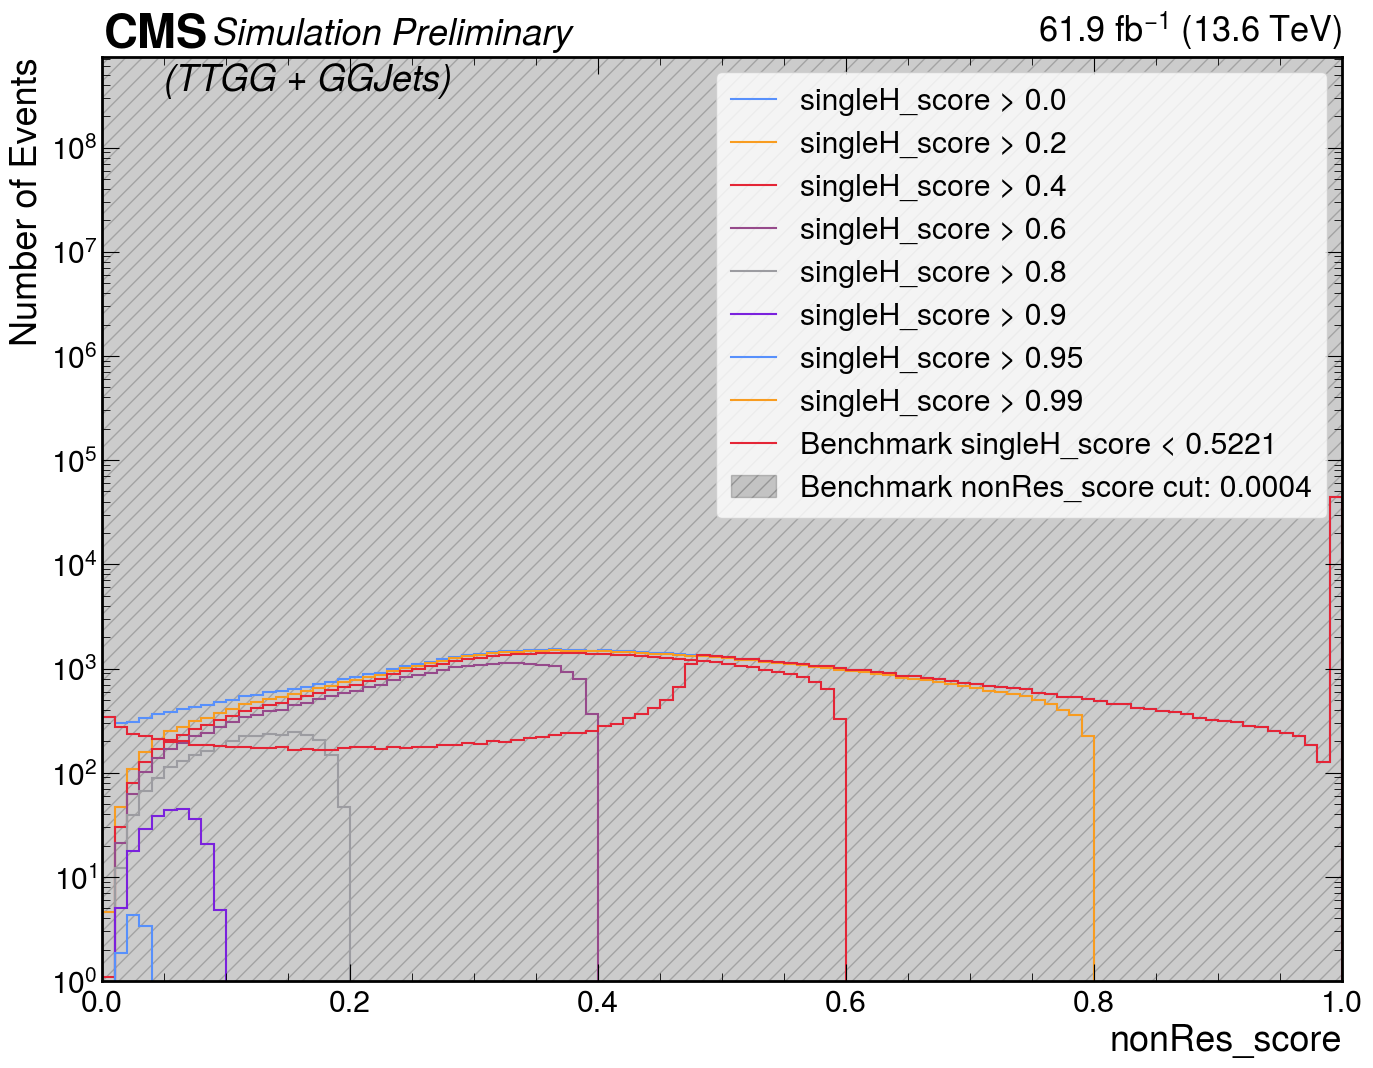

In [387]:
nominals = {
    "HH_score": 0.9354960577617196,
    "nonRes_score": 0.00042766399533097953,
    "ttH_score": 0.5339686443021779,
    "singleH_score": 0.5221471768416271,
}

xvar = "nonRes_score"
disc = "singleH_score"

save=True
display_nominal_cut_rectangle = True

x_min = 0.0 # 0 default
x_max = 1.0 # 1 default

y_max = None # None -> automatic
y_min = 1e0 # 1e0 default


df_selected = df_pred[((df_pred["sample"] == "TTGG") | (df_pred["sample"] == "GGJets")) & (df_pred[xvar] <= x_max) & (df_pred[xvar] >= x_min)]
# hist = np.histogram(df_selected[xvar].values, bins=50, range=(0, 1))
nbins = 100
histtype='step'
alpha=1.0
discs = [
    0.0, # least selective
    # 0.10, 
    0.20, 
    # 0.30, 
    0.40, 
    # 0.50, 
    0.60, 
    # 0.70, 
    0.80, 
    0.90, 
    0.95, 
    0.99, # most selective
]
# idx_closest_to_nominal_disc = np.argmin(np.abs(np.array(discs) - nominals[disc]))
# discs[idx_closest_to_nominal_disc] = round(nominals[disc], 4)
# if 0.0 not in discs: # ensure 0.0 is always included
#     discs.insert(0, 0.0)
fig, ax = plt.subplots(figsize=(16, 12))
for d in discs:
    # if disc == "HH_score":
    #     _df_selected = df_selected[df_selected[disc] > d]
    #     _label = f"{disc} > {d}"
    # else:
    #     _df_selected = df_selected[df_selected[disc] < d]
    #     # singleH_score < 0.99 -> less selective, mostly background
    #     # singleH
    #     _label = f"{disc} < {d}"
    hep.plot.histplot(
        *np.histogram(df_selected[df_selected[disc] > d][xvar].values, bins=nbins, range=(x_min, x_max), weights=df_selected[df_selected[disc] > d]["weight_tot"].values),
        histtype=histtype,
        alpha=alpha,
        label=f"{disc} > {d}",
        yerr=False,
        w2method='poisson',
        # color='blue',
    )
if disc == "HH_score":
    _df_selected = df_selected[df_selected[disc] > nominals[disc]]
    _label = f"Benchmark {disc} > {nominals[disc]:.4f}"
else:
    _df_selected = df_selected[df_selected[disc] < nominals[disc]]
    _label = f"Benchmark {disc} < {nominals[disc]:.4f}"
hep.plot.histplot(
    *np.histogram(_df_selected[xvar].values, bins=nbins, range=(x_min, x_max), weights=_df_selected["weight_tot"].values),
    histtype=histtype,
    alpha=alpha,
    label=_label,
    yerr=False,
    w2method='poisson',
    # linestyle='-.',
    # linestyle=(0, (5, 10)),
    # color='blue',
)
ax.set_ylim(y_min, y_max)
ax.set_yscale("log")

hep.plot.hist_legend(ax=ax)

hep.cms.label("Preliminary", data=False, lumi=61.9, com="13.6", ax=ax)
hep.cms.text(exp="", text="(TTGG + GGJets)", supp="", ax=ax, loc=1)

hep.yscale_legend(ax=ax, soft_fail=True)

# Vertical line at nominal xvar cut
spanend = 0 if xvar == "HH_score" else 1
span_ymin = 0
span_ymax = 1
# Don't let the span clip with legend
axvspan = ax.axvspan(
    nominals[xvar], 
    spanend, 
    span_ymin, 
    span_ymax, 
    zorder=-10, 
    color='black', 
    linestyle='', 
    hatch='//', 
    # label=f"Benchmark {xvar} cut: {nominals[xvar]:.4f}", 
    alpha=0.2
) if display_nominal_cut_rectangle else None

# sneaky way to add axvspan to legend without redrawing it and blowing up yaxis limits
if display_nominal_cut_rectangle:
    handles, labels = ax.get_legend_handles_labels()
    cut_proxy = Patch(
        facecolor=axvspan.get_facecolor(),
        edgecolor=axvspan.get_edgecolor(),
        linestyle=axvspan.get_linestyle(),
        hatch=axvspan.get_hatch(),
        alpha=axvspan.get_alpha(),
        label=f"Benchmark {xvar} cut: {nominals[xvar]:.4f}",
    )
    handles.append(cut_proxy)
    labels.append(cut_proxy.get_label())
    ax.legend(handles, labels, facecolor="white", fancybox=True, frameon=True, framealpha=0.8) # redraw

plt.ylabel("Number of Events")
plt.xlabel(xvar)
plt.xlim(x_min, x_max)
if save:
    fname = f"plots/TTGG+GGJets_{xvar.replace('_', '')}_selectedby-{disc.replace('_', '')}"
    if x_min > 0.0:
        fname = fname + f"_xmin{x_min}"
    if x_max < 1.0:
        fname = fname + f"_xmax{x_max}"
    if not display_nominal_cut_rectangle:
        fname = fname + "_noNominalCutRectangle"

    if os.path.exists(fname + ".png") or os.path.exists(fname + ".pdf"):
        print("Warning: File exists, appending random integer to filename to avoid overwrite.")
        fname = fname + f"_{random.randint(0, 10000):05d}"
    plt.savefig(fname + ".png", dpi=300, bbox_inches='tight')
    plt.savefig(fname + ".pdf", bbox_inches='tight')
plt.show()

In [11]:
from plotly.subplots import make_subplots
from ipywidgets import FloatSlider, VBox, HBox

import plotly.graph_objects as go

# Constants
HH_base = 0.9354960577617196
nonRes_base = 0.00042766399533097953
ttH_base = 0.5339686443021779
singleH_base = 0.5221471768416271

# Sliders (start at current deltas)
s_HH = FloatSlider(description='HH Δ', value=HH_score_delta, min=-0.3, max=0.3, step=0.005)
s_nonRes = FloatSlider(description='nonRes Δ', value=nonRes_score_delta, min=-0.05, max=0.05, step=0.001)
s_ttH = FloatSlider(description='ttH Δ', value=ttH_score_delta, min=-0.3, max=0.3, step=0.005)
s_singleH = FloatSlider(description='singleH Δ', value=singleH_score_delta, min=-0.3, max=0.3, step=0.005)

# FigureWidget with subplots
figw = go.FigureWidget(make_subplots(rows=1, cols=2, column_widths=[0.55, 0.45],
                                     subplot_titles=("m_jj vs m_γγ (SR1 selection)", "m_jj distributions")))

# Initialize traces
figw.add_trace(go.Histogram2d(x=[], y=[], colorscale='Viridis', showscale=True,
                              xbins=dict(start=80, end=190, size=(190-80)/100),
                              ybins=dict(start=100, end=180, size=(180-100)/100)),
               row=1, col=1)

figw.add_trace(go.Histogram(x=[], name='mass < 125', histnorm='probability density',
                            marker_color='blue', opacity=0.55, xbins=dict(start=80, end=190, size=(190-80)/Nbins)),
               row=1, col=2)

figw.add_trace(go.Histogram(x=[], name='mass ≥ 125', histnorm='probability density',
                            marker_color='red', opacity=0.55, xbins=dict(start=80, end=190, size=(190-80)/Nbins)),
               row=1, col=2)

figw.add_trace(go.Histogram(x=[], name='inclusive', histnorm='probability density',
                            marker_color='black', opacity=0.55, xbins=dict(start=80, end=190, size=(190-80)/Nbins)),
               row=1, col=2)

figw.update_layout(bargap=0.05)

ann_id = 'stats_annotation'
figw.add_annotation(dict(text='', x=0.5, y=0.95, xref='x2 domain', yref='y2 domain',
                         showarrow=False, font=dict(size=12), align='left'), name=ann_id)

def apply_selection(dHH, dNonRes, dTtH, dSingleH):
    sr_mask = (
        (df_pred["HH_score"] > HH_base + dHH) &
        (df_pred["nonRes_score"] < nonRes_base - dNonRes) &
        (df_pred["ttH_score"] < ttH_base - dTtH) &
        (df_pred["singleH_score"] < singleH_base - dSingleH) &
        (df_pred["sample"].isin(SAMPLES))
    )
    return df_pred[sr_mask]

def update(_=None):
    df_sel = apply_selection(s_HH.value, s_nonRes.value, s_ttH.value, s_singleH.value)
    if df_sel.empty:
        # Clear traces
        for t in figw.data:
            t.x = []
            if hasattr(t, 'y'):
                t.y = []
        figw.layout.annotations[0].text = 'No events pass selection'
        return
    # 2D histogram data
    figw.data[0].x = df_sel["nonResReg_dijet_mass_DNNreg"]
    figw.data[0].y = df_sel["mass"]

    # Split regions
    df_hi = df_sel[df_sel["mass"] >= 125]
    df_lo = df_sel[df_sel["mass"] < 125]

    figw.data[1].x = df_lo["nonResReg_dijet_mass_DNNreg"]
    figw.data[2].x = df_hi["nonResReg_dijet_mass_DNNreg"]
    figw.data[3].x = df_sel["nonResReg_dijet_mass_DNNreg"]

    # Weighted correlation
    try:
        wp_corr = corr(df_sel["mass"].values, df_sel["nonResReg_dijet_mass_DNNreg"].values, df_sel["weight_tot"].values)
    except Exception:
        wp_corr = float('nan')

    figw.layout.annotations[0].text = (
        f"Samples: {', '.join(SAMPLES)}<br>"
        f"Events: {df_sel.shape[0]}<br>"
        f"Weighted Pearson corr: {wp_corr:.3f}<br>"
        f"Δ(HH, nonRes, ttH, singleH)=({s_HH.value:+.3f}, {s_nonRes.value:+.3f}, {s_ttH.value:+.3f}, {s_singleH.value:+.3f})"
    )

# Connect sliders
for sl in (s_HH, s_nonRes, s_ttH, s_singleH):
    sl.observe(update, names='value')

update()
display(VBox([HBox([s_HH, s_nonRes]), HBox([s_ttH, s_singleH]), figw]))


/Users/benls/miniforge3/envs/HHbbgg_classifier/lib/python3.13/site-packages/mplhep/utils.py:652: RuntimeWarning:

All sumw are zero!  Cannot compute meaningful error bars



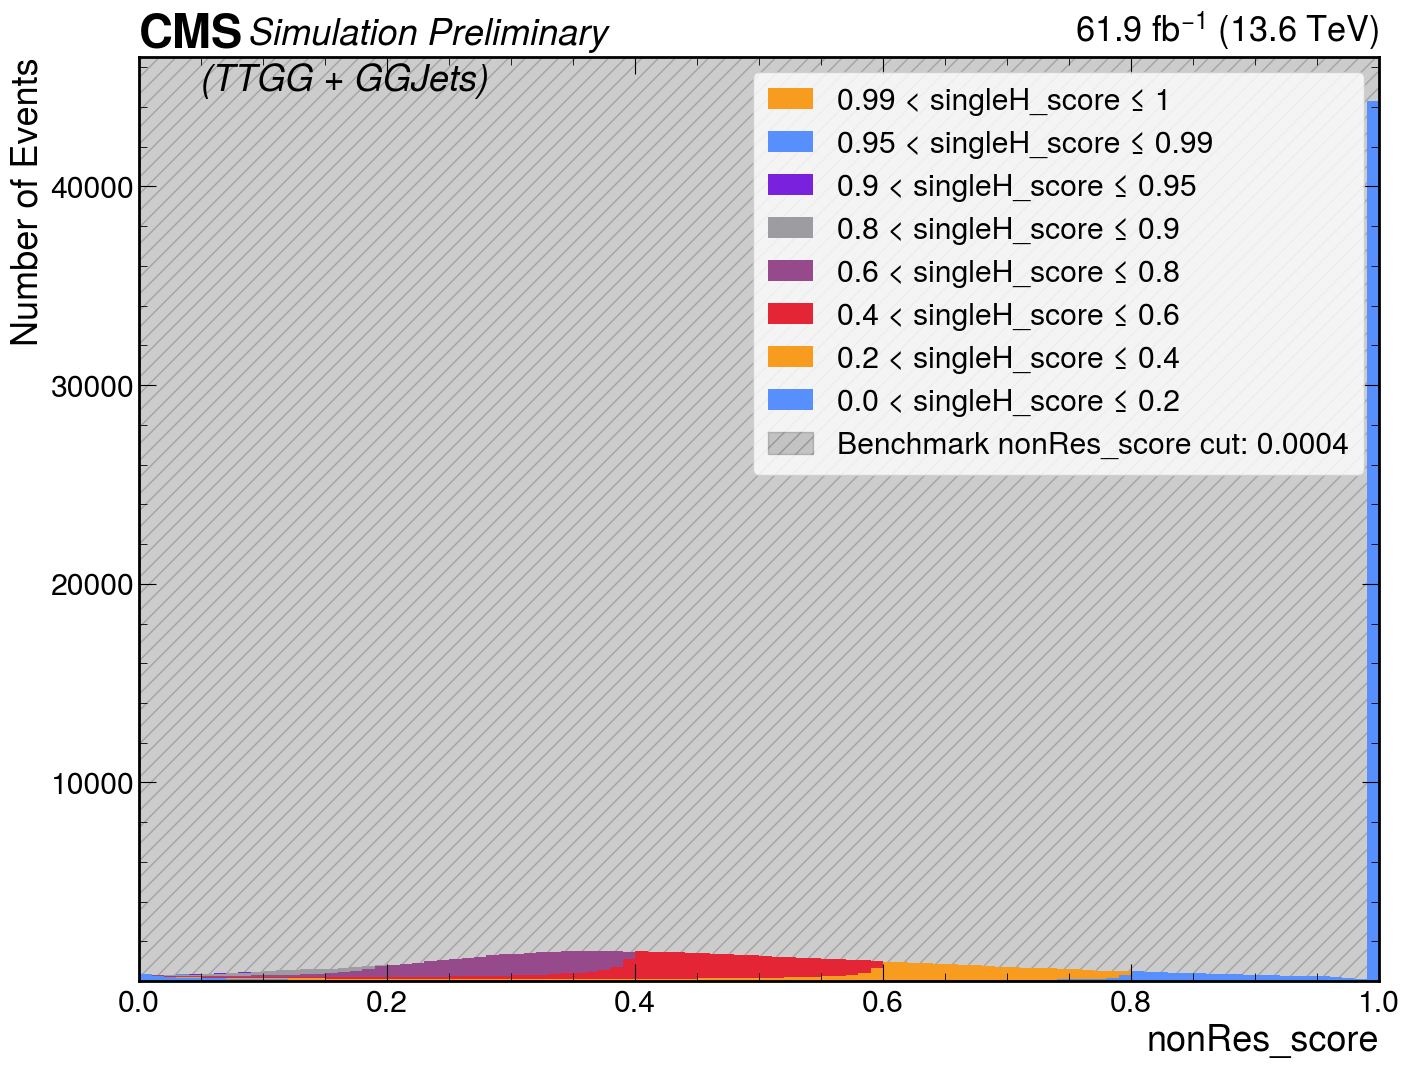

In [399]:
nominals = {
    "HH_score": 0.9354960577617196,
    "nonRes_score": 0.00042766399533097953,
    "ttH_score": 0.5339686443021779,
    "singleH_score": 0.5221471768416271,
}

xvar = "nonRes_score"
disc = "singleH_score"

save=True
display_nominal_cut_rectangle = True

x_min = 0.0 # 0 default
x_max = 1.0 # 1 default

y_max = None # None -> automatic
y_min = 1e0 # 1e0 default


df_selected = df_pred[((df_pred["sample"] == "TTGG") | (df_pred["sample"] == "GGJets")) & (df_pred[xvar] <= x_max) & (df_pred[xvar] >= x_min)]
# hist = np.histogram(df_selected[xvar].values, bins=50, range=(0, 1))
nbins = 100
histtype='fill'
alpha=1.0
discs = [
    0.0, # least selective
    0.20, 
    # 0.30, 
    0.40, 
    # 0.50, 
    0.60, 
    # 0.70, 
    0.80, 
    0.90, 
    0.95, 
    0.99, # most selective
]
# idx_closest_to_nominal_disc = np.argmin(np.abs(np.array(discs) - nominals[disc]))
# discs[idx_closest_to_nominal_disc] = round(nominals[disc], 4)
# if 0.0 not in discs: # ensure 0.0 is always included
#     discs.insert(0, 0.0)
fig, ax = plt.subplots(figsize=(16, 12))
_hists = []
_labels = []
for i, d in enumerate(discs):
    # if disc == "HH_score":
    #     _df_selected = df_selected[df_selected[disc] > d]
    #     _label = f"{disc} > {d}"
    # else:
    #     _df_selected = df_selected[df_selected[disc] < d]
    #     # singleH_score < 0.99 -> less selective, mostly background
    #     # singleH
    #     _label = f"{disc} < {d}"
    d_up = discs[i+1] if i+1 < len(discs) else 1
    d_low = d
    _df_selected = df_selected[(df_selected[disc] > d_low) & (df_selected[disc] <= d_up)]
    _hists.append(np.histogram(_df_selected[xvar].values, bins=nbins, range=(x_min, x_max), weights=_df_selected["weight_tot"].values))
    _labels.append(f"{d_low} < {disc} ≤ {d_up}")


hep.plot.histplot(
    _hists,
    histtype=histtype,
    alpha=alpha,
    label=_labels,
    yerr=False,
    stack=True,
    w2method='poisson',
    # color='blue',
)
# if disc == "HH_score":
#     _df_selected = df_selected[df_selected[disc] > nominals[disc]]
#     _label = f"Benchmark {disc} > {nominals[disc]:.4f}"
# else:
#     _df_selected = df_selected[df_selected[disc] < nominals[disc]]
#     _label = f"Benchmark {disc} < {nominals[disc]:.4f}"
# hep.plot.histplot(
#     *np.histogram(_df_selected[xvar].values, bins=nbins, range=(x_min, x_max), weights=_df_selected["weight_tot"].values),
#     histtype=histtype,
#     alpha=alpha,
#     label=_label,
#     yerr=False,
#     w2method='poisson',
#     # linestyle='-.',
#     # linestyle=(0, (5, 10)),
#     # color='blue',
# )
ax.set_ylim(y_min, y_max)
# ax.set_yscale("log")

hep.plot.hist_legend(ax=ax)

hep.cms.label("Preliminary", data=False, lumi=61.9, com="13.6", ax=ax)
hep.cms.text(exp="", text="(TTGG + GGJets)", supp="", ax=ax, loc=1)

hep.yscale_legend(ax=ax, soft_fail=True)

# Vertical line at nominal xvar cut
spanend = 0 if xvar == "HH_score" else 1
span_ymin = 0
span_ymax = 1
# Don't let the span clip with legend
axvspan = ax.axvspan(
    nominals[xvar], 
    spanend, 
    span_ymin, 
    span_ymax, 
    zorder=-10, 
    color='black', 
    linestyle='', 
    hatch='//', 
    # label=f"Benchmark {xvar} cut: {nominals[xvar]:.4f}", 
    alpha=0.2
) if display_nominal_cut_rectangle else None

# sneaky way to add axvspan to legend without redrawing it and blowing up yaxis limits
if display_nominal_cut_rectangle:
    handles, labels = ax.get_legend_handles_labels()
    cut_proxy = Patch(
        facecolor=axvspan.get_facecolor(),
        edgecolor=axvspan.get_edgecolor(),
        linestyle=axvspan.get_linestyle(),
        hatch=axvspan.get_hatch(),
        alpha=axvspan.get_alpha(),
        label=f"Benchmark {xvar} cut: {nominals[xvar]:.4f}",
    )
    handles.append(cut_proxy)
    labels.append(cut_proxy.get_label())
    ax.legend(handles, labels, facecolor="white", fancybox=True, frameon=True, framealpha=0.8) # redraw

plt.ylabel("Number of Events")
plt.xlabel(xvar)
plt.xlim(x_min, x_max)
if save:
    fname = f"plots/TTGG+GGJets_{xvar.replace('_', '')}_selectedby-{disc.replace('_', '')}"
    if x_min > 0.0:
        fname = fname + f"_xmin{x_min}"
    if x_max < 1.0:
        fname = fname + f"_xmax{x_max}"
    if not display_nominal_cut_rectangle:
        fname = fname + "_noNominalCutRectangle"

    if os.path.exists(fname + ".png") or os.path.exists(fname + ".pdf"):
        print("Warning: File exists, appending random integer to filename to avoid overwrite.")
        fname = fname + f"_{random.randint(0, 10000):05d}"
    plt.savefig(fname + ".png", dpi=300, bbox_inches='tight')
    plt.savefig(fname + ".pdf", bbox_inches='tight')
plt.show()